In [21]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

df = pl.read_parquet("C:\\Users\\bened\\user_trajectory\\494-user-trajectories\\students\\benedict\\spring\\ArchiveUserTraj\\sampled_user_month_traj.parquet")

In [22]:
df.columns

['participantId',
 'userMonth',
 'sportsNotesWritten',
 'diaries_&_daily_lifeNotesWritten',
 'business_&_entrepreneursNotesWritten',
 'science_&_technologyNotesWritten',
 'news_&_social_concernNotesWritten',
 'otherNotesWritten',
 'calendarMonth',
 'notesWritten',
 'hitRate',
 'hits',
 'avgNoteFactor',
 'avgNoteIntercept',
 'uniqueTopicsTargeted',
 'avgRatingsEarned',
 'antiDemNotes',
 'proDemNotes',
 'antiRepNotes',
 'proRepNotes',
 'notesOnDems',
 'notesOnReps',
 'demAlignedNotes',
 'repAlignedNotes',
 'demAlignedLessRepAlignedNotes',
 'sportsNotesRated',
 'diaries_&_daily_lifeNotesRated',
 'business_&_entrepreneursNotesRated',
 'science_&_technologyNotesRated',
 'news_&_social_concernNotesRated',
 'otherNotesRated',
 'notesRated',
 'avgHelpfulFactor',
 'avgNotHelpfulFactor',
 'avgHelpfulIntercept',
 'avgNotHelpfulIntercept',
 'correctHelpfuls',
 'correctNotHelpfuls',
 'posFactorRatedHelpful',
 'posFactorRatedNotHelpful',
 'negFactorRatedHelpful',
 'negFactorRatedNotHelpful',
 'propC

In [50]:
df['activeMonth'].unique

<bound method Series.unique of shape: (294_573,)
Series: 'activeMonth' [bool]
[
	true
	false
	false
	true
	false
	…
	false
	true
	false
	true
	false
]>

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

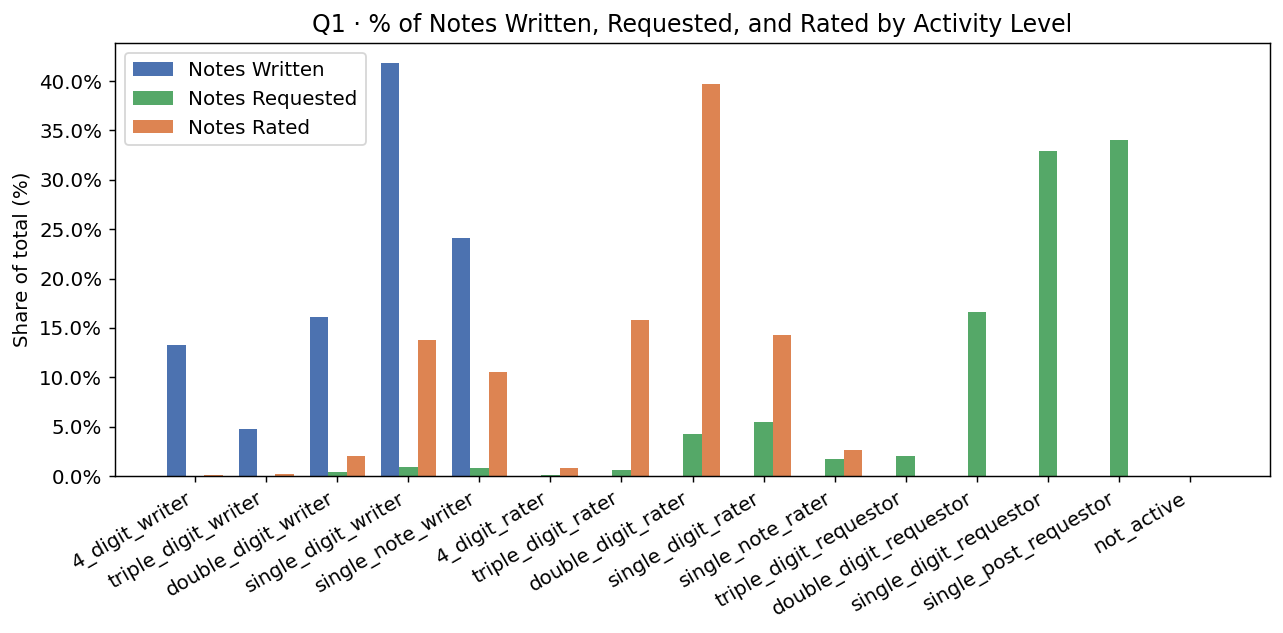

month_role,total_notes,total_requested,total_ratings,pct_notes,pct_requested,pct_ratings
enum,u32,u32,u32,f64,f64,f64
"""4_digit_writer""",1460,0,1214,13.287222,0.0,0.146168
"""triple_digit_writer""",524,0,2014,4.768839,0.0,0.242489
"""double_digit_writer""",1765,190,16720,16.062978,0.377598,2.013117
"""single_digit_writer""",4591,480,114290,41.781944,0.953933,13.760711
"""single_note_writer""",2648,430,87841,24.099017,0.854565,10.576206
…,…,…,…,…,…,…
"""triple_digit_requestor""",0,1039,0,0.0,2.064867,0.0
"""double_digit_requestor""",0,8379,0,0.0,16.652093,0.0
"""single_digit_requestor""",0,16534,0,0.0,32.859017,0.0


In [41]:
q1 = (
    df.group_by("month_role")
    .agg(
        pl.col("notesWritten").sum().alias("total_notes"),
        pl.col("notesRequested").sum().alias("total_requested"),
        pl.col("notesRated").sum().alias("total_ratings"),
    )
    .with_columns([
        (pl.col("total_notes")      / pl.col("total_notes").sum()      * 100).alias("pct_notes"),
        (pl.col("total_requested")  / pl.col("total_requested").sum()  * 100).alias("pct_requested"),
        (pl.col("total_ratings")    / pl.col("total_ratings").sum()    * 100).alias("pct_ratings"),
    ])
    .sort("month_role")
)

roles  = q1["month_role"].to_list()
x      = np.arange(len(roles))
w      = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, q1["pct_notes"].to_list(),     w, label="Notes Written",    color="#4C72B0")
ax.bar(x,      q1["pct_requested"].to_list(), w, label="Notes Requested",  color="#55A868")
ax.bar(x + w,  q1["pct_ratings"].to_list(),   w, label="Notes Rated",      color="#DD8452")

ax.set_xticks(x); ax.set_xticklabels(roles, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_ylabel("Share of total (%)"); ax.set_title("Q1 · % of Notes Written, Requested, and Rated by Activity Level")
ax.legend(); plt.tight_layout(); plt.show()
q1

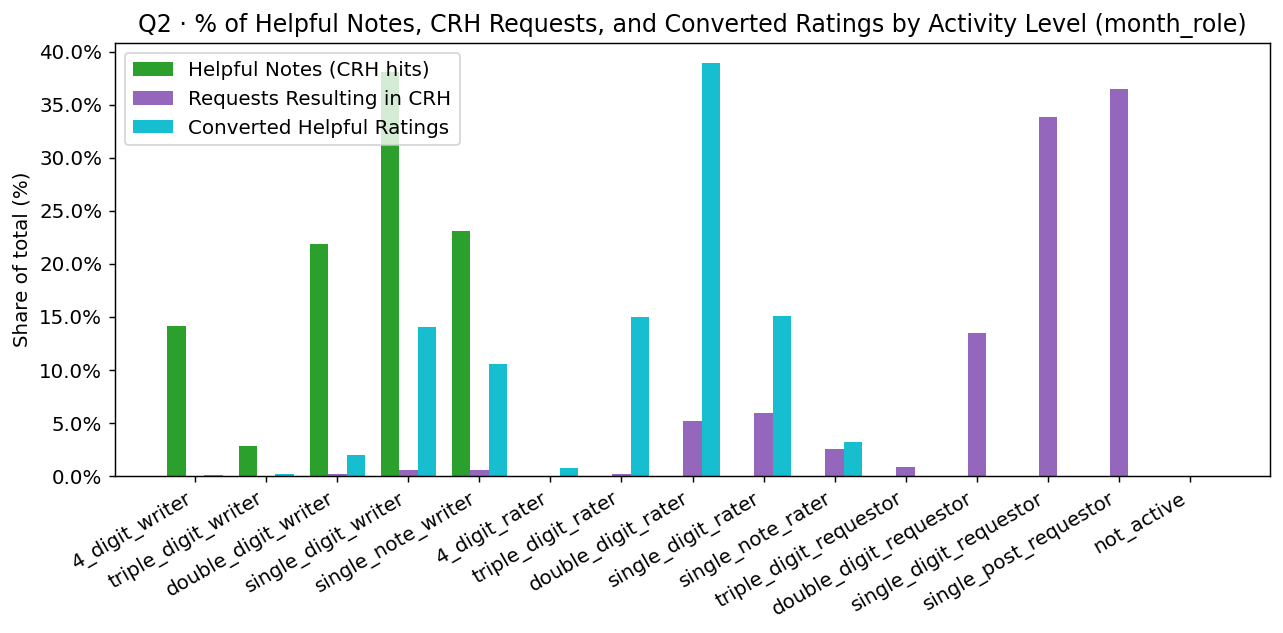

month_role,helpful_notes,helpful_ratings,crh_requests,pct_helpful_notes,pct_crh_requests,pct_helpful_ratings
enum,u32,u32,u32,f64,f64,f64
"""4_digit_writer""",157,467,0,14.156898,0.0,0.101516
"""triple_digit_writer""",31,1014,0,2.795311,0.0,0.220421
"""double_digit_writer""",243,9280,9,21.911632,0.196678,2.017269
"""single_digit_writer""",422,64606,28,38.052299,0.611888,14.043928
"""single_note_writer""",256,48752,27,23.083859,0.590035,10.597616
…,…,…,…,…,…,…
"""triple_digit_requestor""",0,0,41,0.0,0.895979,0.0
"""double_digit_requestor""",0,0,619,0.0,13.527098,0.0
"""single_digit_requestor""",0,0,1549,0.0,33.850524,0.0


In [49]:
q2 = (
    df.group_by("month_role")
    .agg(
        pl.col("hits").sum().alias("helpful_notes"),           # CRH notes
        (pl.col("correctHelpfuls") + pl.col("correctNotHelpfuls")).sum().alias("helpful_ratings"),
        pl.col("numRequestsResultingInCrh").sum().alias("crh_requests"),
    )
    .with_columns([
        (pl.col("helpful_notes")   / pl.col("helpful_notes").sum()   * 100).alias("pct_helpful_notes"),
        (pl.col("crh_requests")    / pl.col("crh_requests").sum()    * 100).alias("pct_crh_requests"),
        (pl.col("helpful_ratings") / pl.col("helpful_ratings").sum() * 100).alias("pct_helpful_ratings"),
    ])
    .sort("month_role")
)

roles  = q2["month_role"].to_list()
x      = np.arange(len(roles))
w      = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, q2["pct_helpful_notes"].to_list(),    w, label="Helpful Notes (CRH hits)",         color="#2ca02c")
ax.bar(x,     q2["pct_crh_requests"].to_list(),     w, label="Requests Resulting in CRH",       color="#9467bd")
ax.bar(x + w, q2["pct_helpful_ratings"].to_list(),  w, label="Converted Helpful Ratings",       color="#17becf")

ax.set_xticks(x); ax.set_xticklabels(roles, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_ylabel("Share of total (%)"); ax.set_title("Q2 · % of Helpful Notes, CRH Requests, and Converted Ratings by Activity Level (month_role)")
ax.legend(); plt.tight_layout(); plt.show()
q2

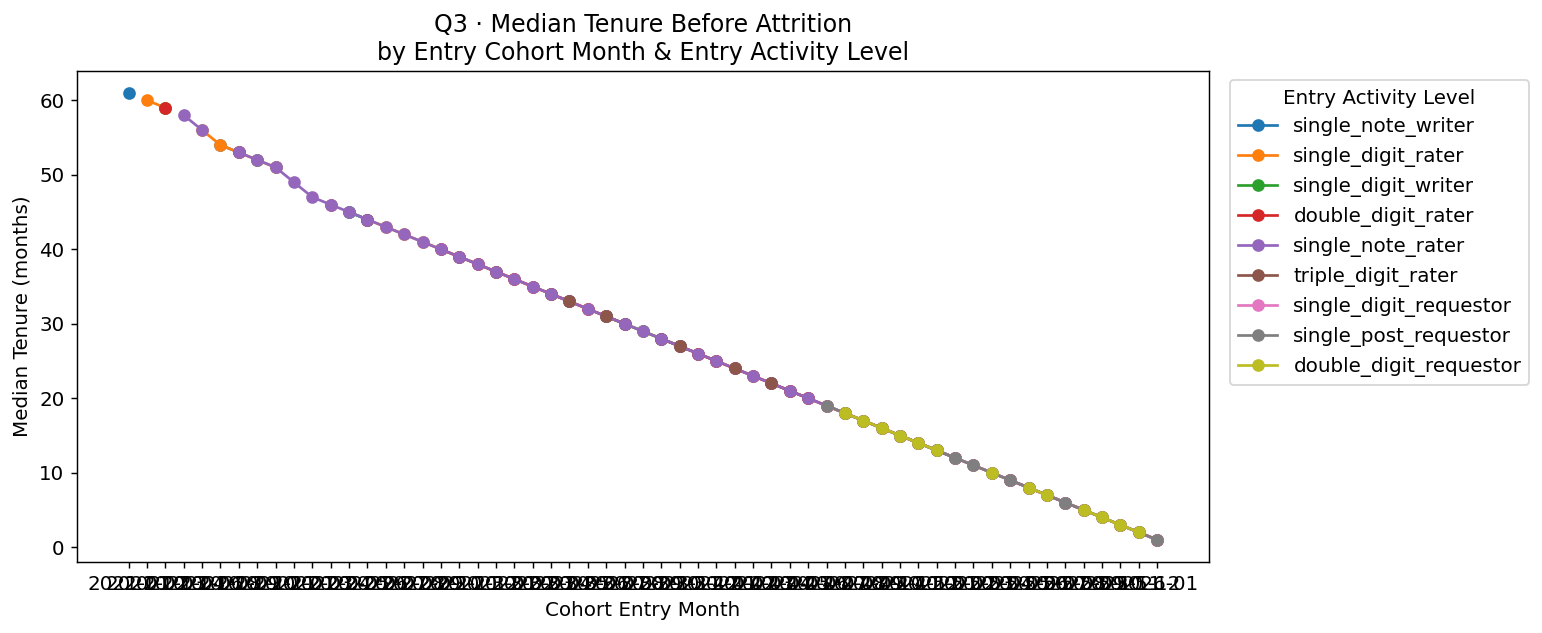

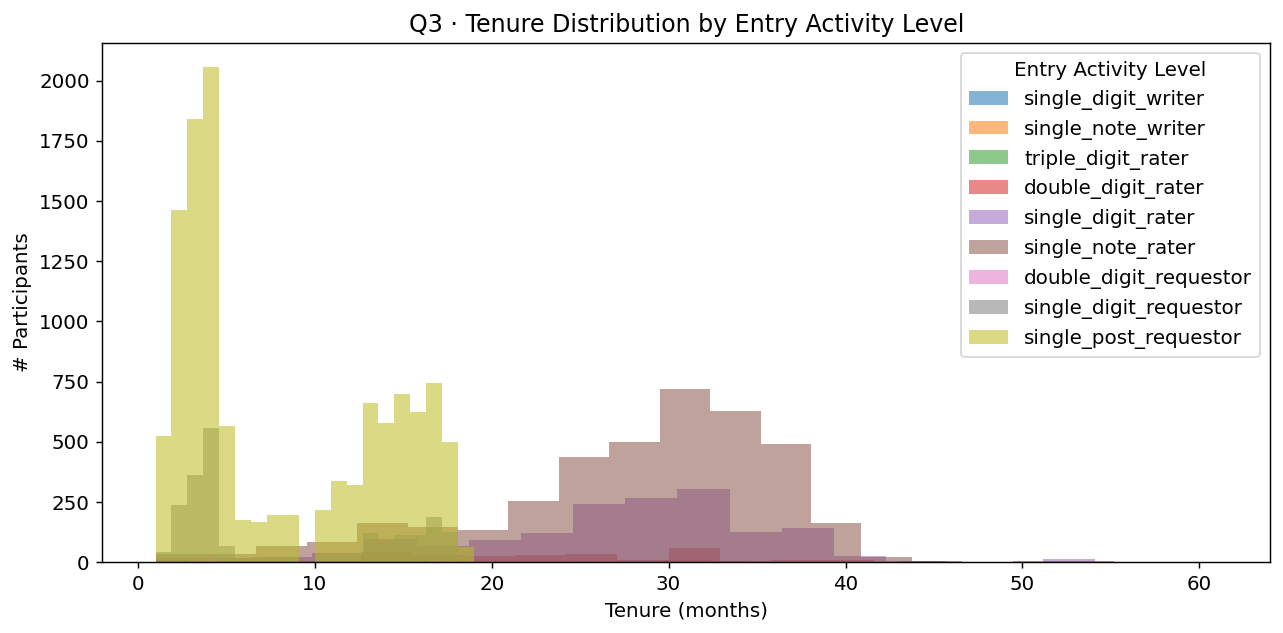

In [52]:
# "Entry" = first calendarMonth a participant appears
# "Exit"  = last calendarMonth they appear
# Tenure  = exit - entry (in months)

cohort = (
    df.group_by("participantId")
    .agg([
        pl.col("calendarMonth").min().alias("entry_month"),
        pl.col("calendarMonth").max().alias("exit_month"),
        # activity level at entry = month_role in their first month
        pl.col("month_role")
          .sort_by(pl.col("calendarMonth"))
          .first()
          .alias("entry_role"),
    ])
    .with_columns(
        [
            pl.col("entry_month").str.slice(0, 4).cast(pl.Int64).alias("entry_year"),
            pl.col("entry_month").str.slice(5, 2).cast(pl.Int64).alias("entry_month_num"),
            pl.col("exit_month").str.slice(0, 4).cast(pl.Int64).alias("exit_year"),
            pl.col("exit_month").str.slice(5, 2).cast(pl.Int64).alias("exit_month_num"),
        ]
    )
    .with_columns(
        (
            (pl.col("exit_year") * 12 + pl.col("exit_month_num"))
            - (pl.col("entry_year") * 12 + pl.col("entry_month_num"))
        ).alias("tenure_months")
    )
    .drop(["entry_year", "entry_month_num", "exit_year", "exit_month_num"])
)

# Summarise median tenure by entry_month × entry_role
summary = (
    cohort.group_by(["entry_month", "entry_role"])
    .agg(pl.col("tenure_months").median().alias("median_tenure"))
    .sort(["entry_month", "entry_role"])
)

# Pivot so each activity level is a line
pivot = summary.pivot(index="entry_month", on="entry_role", values="median_tenure").sort("entry_month")

fig, ax = plt.subplots(figsize=(12, 5))
for col in pivot.columns:
    if col == "entry_month":
        continue
    ax.plot(pivot["entry_month"].to_list(), pivot[col].to_list(), marker="o", label=col)

ax.set_xlabel("Cohort Entry Month"); ax.set_ylabel("Median Tenure (months)")
ax.set_title("Q3 · Median Tenure Before Attrition\nby Entry Cohort Month & Entry Activity Level")
ax.legend(title="Entry Activity Level", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

# Also show raw distribution of tenure by entry_role
fig, ax = plt.subplots(figsize=(10, 5))
for role in cohort["entry_role"].unique().to_list():
    vals = cohort.filter(pl.col("entry_role") == role)["tenure_months"].to_list()
    ax.hist(vals, bins=20, alpha=0.55, label=str(role))

ax.set_xlabel("Tenure (months)"); ax.set_ylabel("# Participants")
ax.set_title("Q3 · Tenure Distribution by Entry Activity Level")
ax.legend(title="Entry Activity Level"); plt.tight_layout(); plt.show()

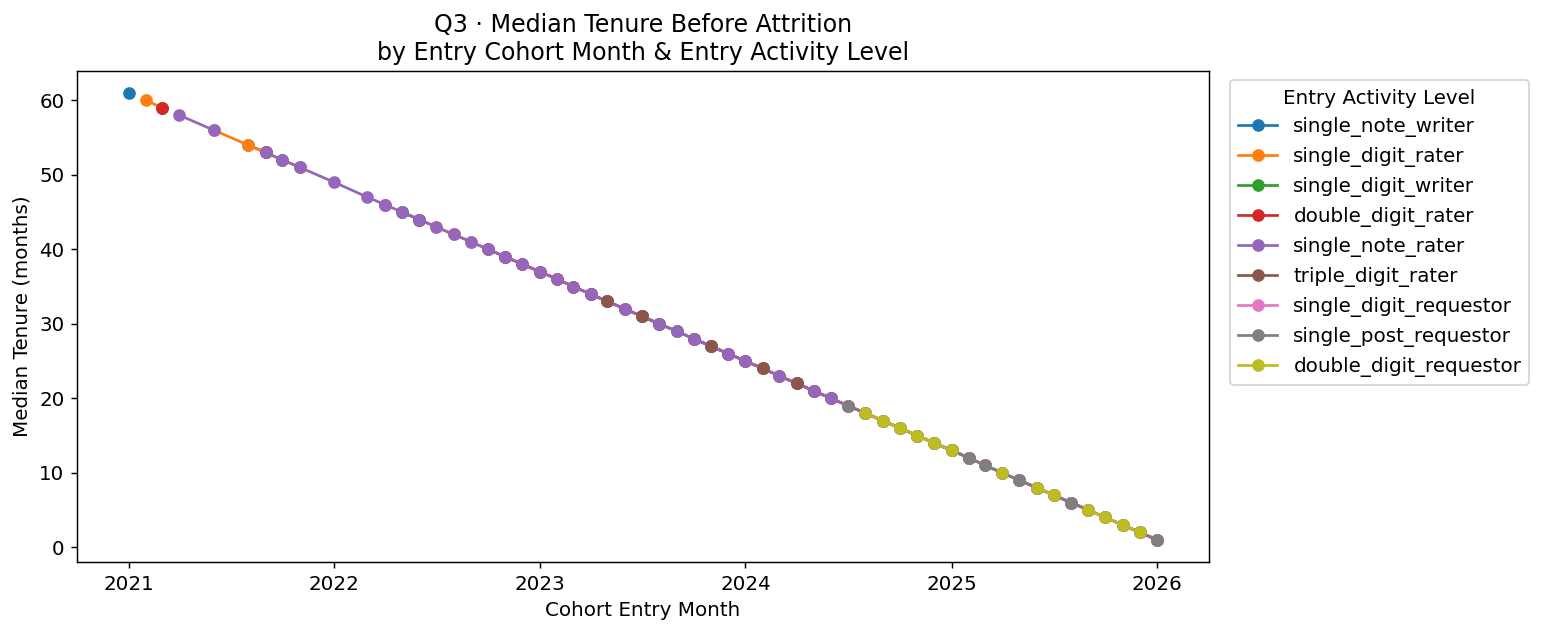

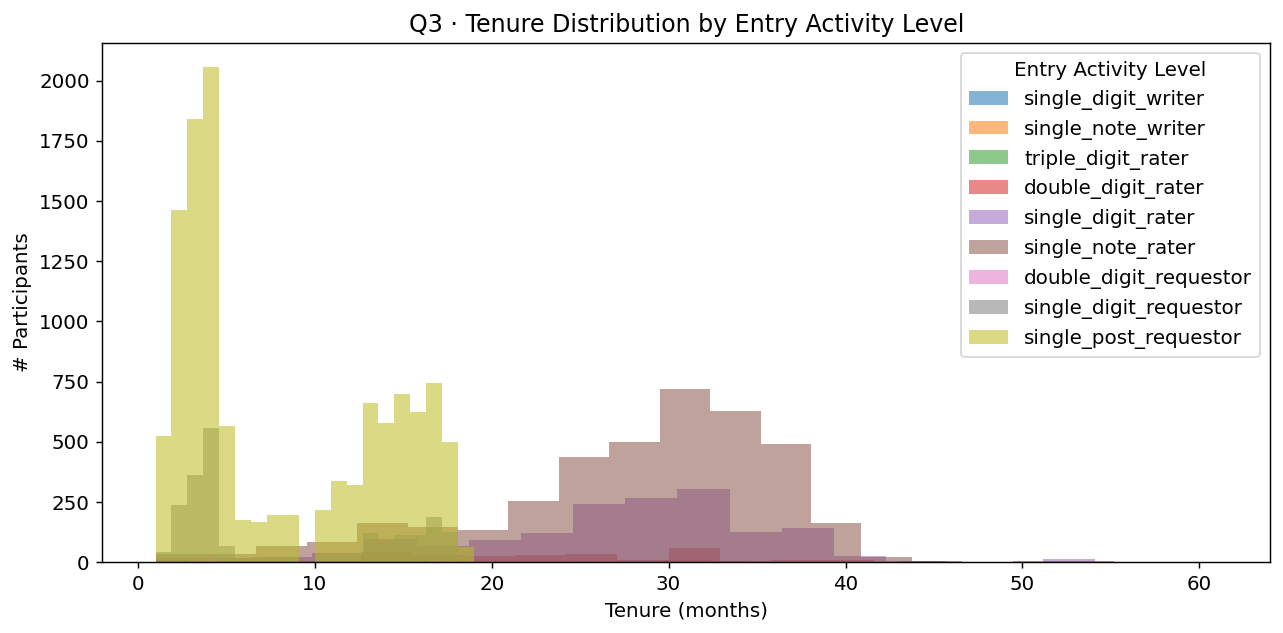

In [54]:
# "Entry" = first calendarMonth a participant appears
# "Exit"  = last calendarMonth they appear
# Tenure  = exit - entry (in months)

cohort = (
    df.with_columns(
        pl.col("calendarMonth").str.strptime(pl.Date, "%Y-%m").alias("calendar_month_date")
    )
    .group_by("participantId")
    .agg([
        pl.col("calendar_month_date").min().alias("entry_month"),
        pl.col("calendar_month_date").max().alias("exit_month"),
        pl.col("month_role")
          .sort_by(pl.col("calendar_month_date"))
          .first()
          .alias("entry_role"),
    ])
    .with_columns(
        (
            (pl.col("exit_month").dt.year() * 12 + pl.col("exit_month").dt.month())
            - (pl.col("entry_month").dt.year() * 12 + pl.col("entry_month").dt.month())
        ).alias("tenure_months")
    )
)

# Summarise median tenure by entry_month × entry_role
summary = (
    cohort.group_by(["entry_month", "entry_role"])
    .agg(pl.col("tenure_months").median().alias("median_tenure"))
    .sort(["entry_month", "entry_role"])
)

# Pivot so each activity level is a line
pivot = summary.pivot(index="entry_month", on="entry_role", values="median_tenure").sort("entry_month")

fig, ax = plt.subplots(figsize=(12, 5))
for col in pivot.columns:
    if col == "entry_month":
        continue
    ax.plot(pivot["entry_month"].to_list(), pivot[col].to_list(), marker="o", label=col)

ax.set_xlabel("Cohort Entry Month"); ax.set_ylabel("Median Tenure (months)")
ax.set_title("Q3 · Median Tenure Before Attrition\nby Entry Cohort Month & Entry Activity Level")
ax.legend(title="Entry Activity Level", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

# Also show raw distribution of tenure by entry_role
fig, ax = plt.subplots(figsize=(10, 5))
for role in cohort["entry_role"].unique().to_list():
    vals = cohort.filter(pl.col("entry_role") == role)["tenure_months"].to_list()
    ax.hist(vals, bins=20, alpha=0.55, label=str(role))

ax.set_xlabel("Tenure (months)"); ax.set_ylabel("# Participants")
ax.set_title("Q3 · Tenure Distribution by Entry Activity Level")
ax.legend(title="Entry Activity Level"); plt.tight_layout(); plt.show()

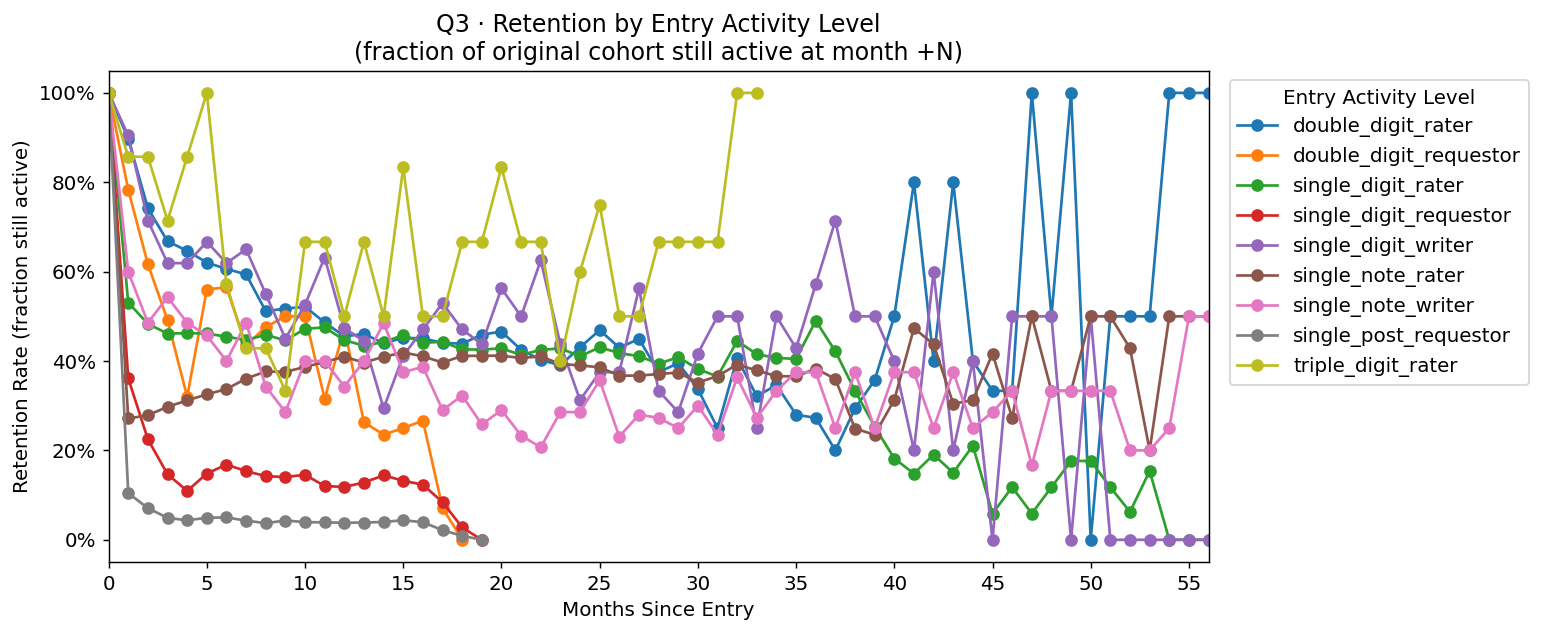

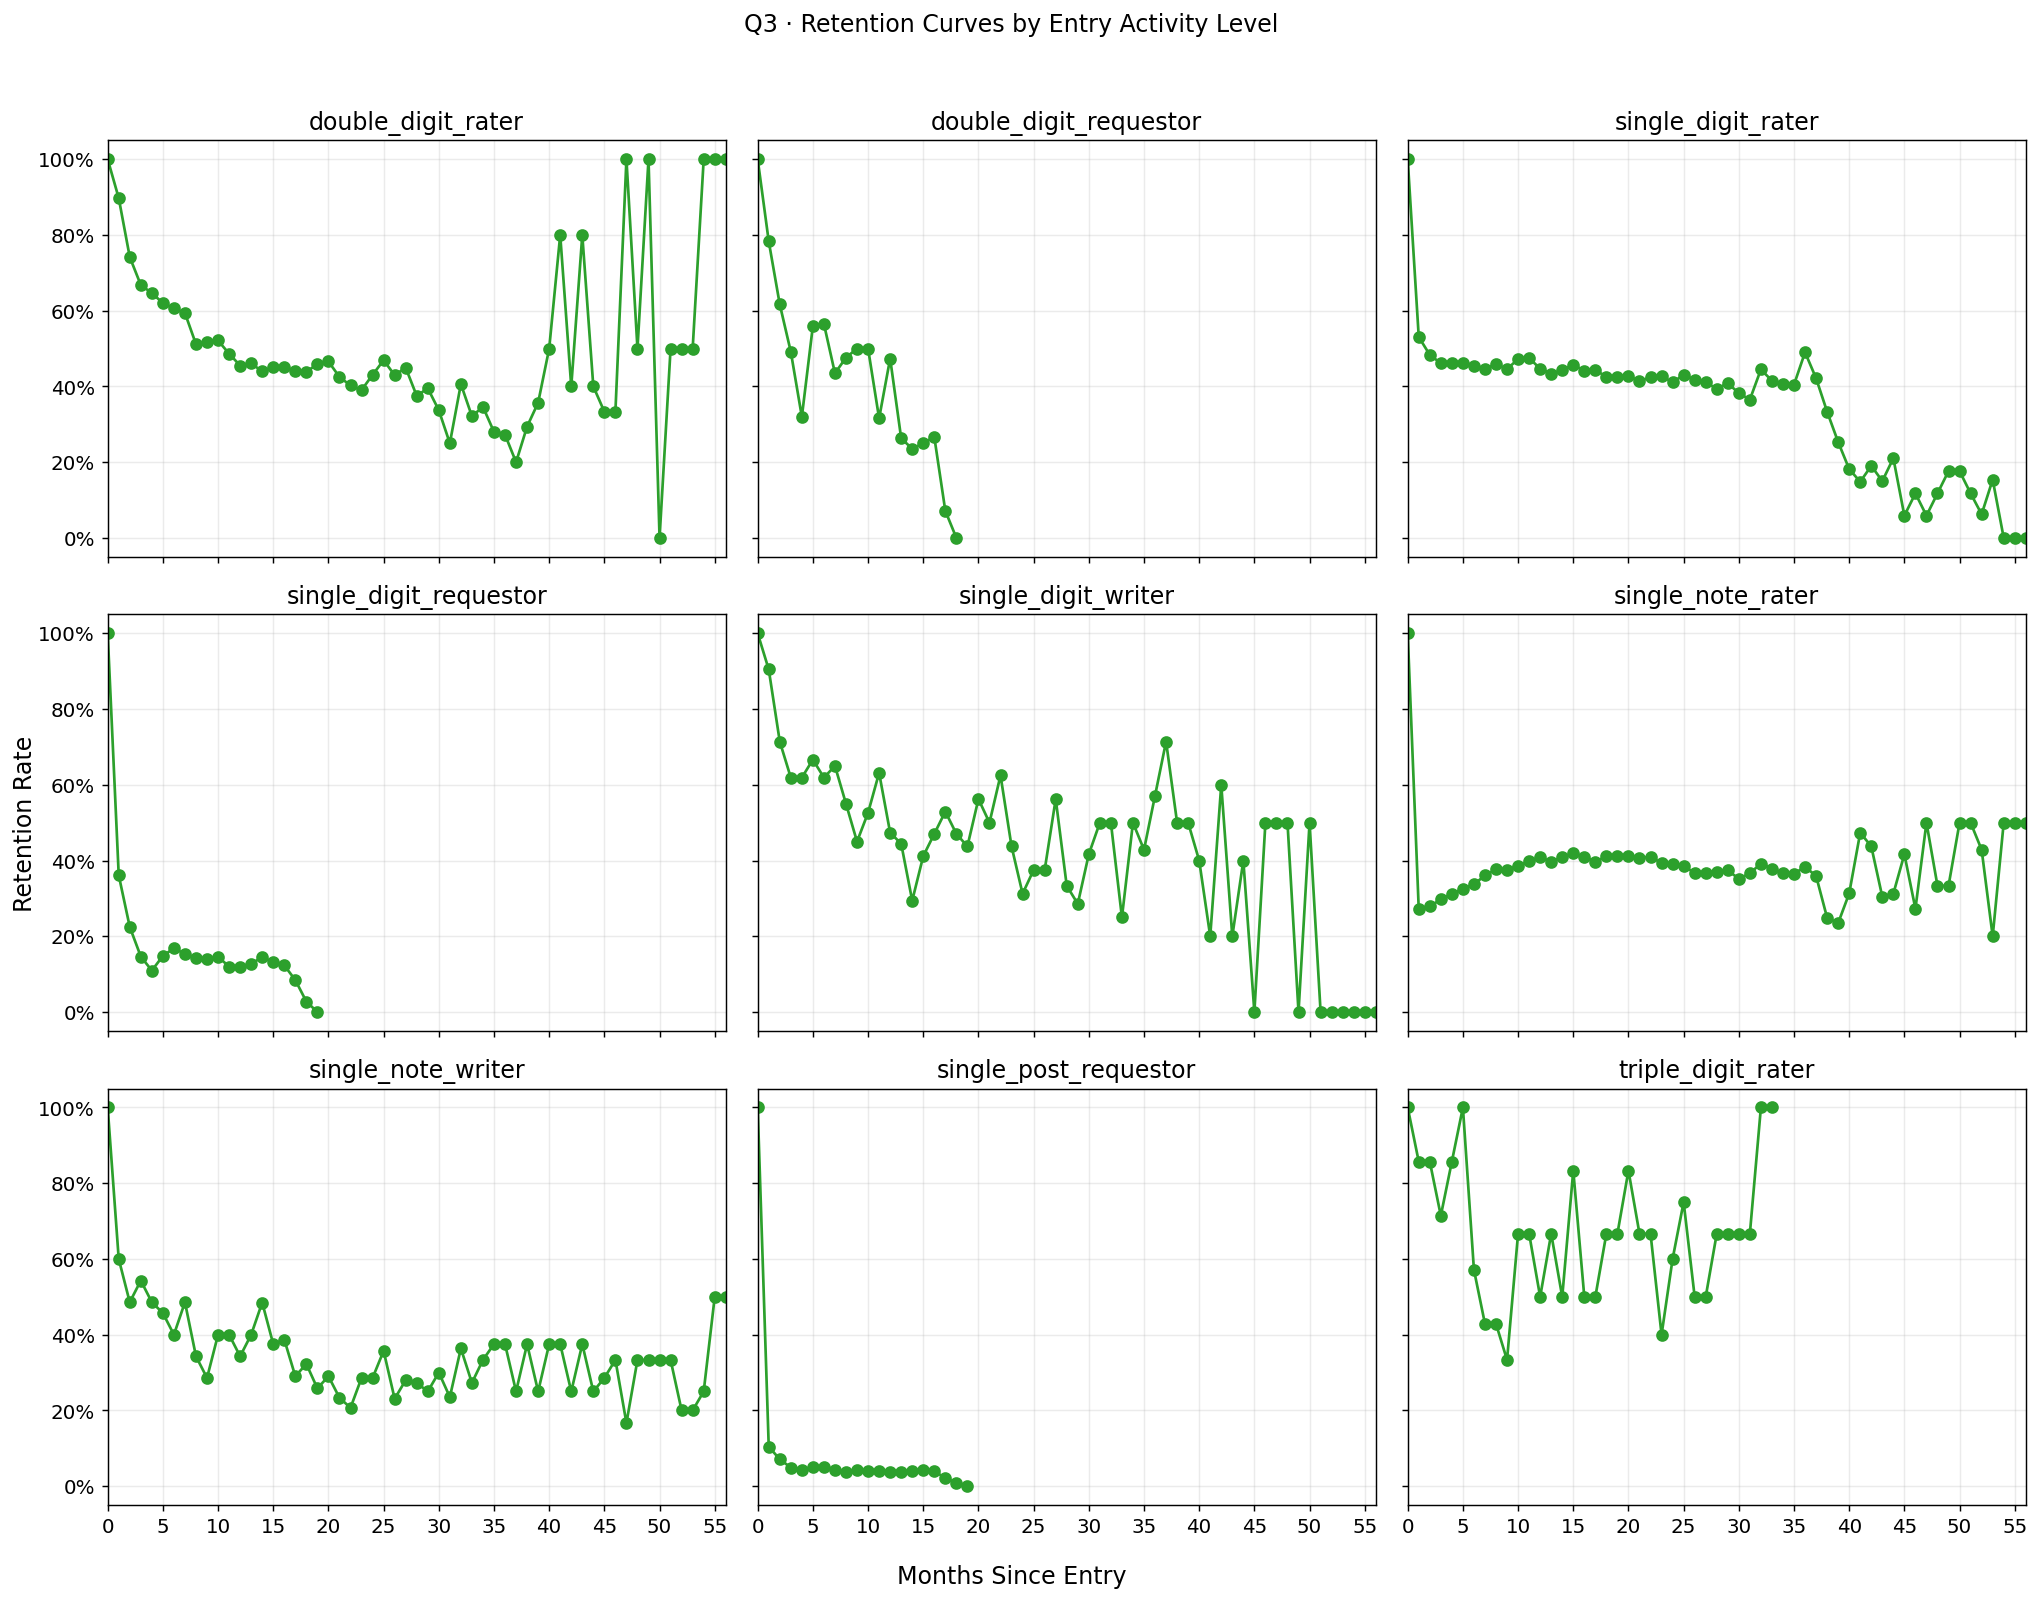

In [66]:
# Survival-style retention: for each participant, track whether they're still active at month +N
# Only cohorts with enough history to reach month +N are included at that time point

max_window = 56  # how many months out to track

# Get each participant's entry month and entry role
entrants = (
    df.filter(pl.col("activeMonth"))
    .group_by("participantId")
    .agg([
        pl.col("userMonth").min().alias("entry_month"),
        pl.col("month_role").sort_by("userMonth").first().alias("entry_role"),
    ])
)

# Join back to full df to get activeMonth at each userMonth
joined = (
    df.join(entrants, on="participantId", how="left")
    .with_columns(
        (pl.col("userMonth") - pl.col("entry_month")).alias("months_since_entry")
    )
    .filter(pl.col("months_since_entry").is_between(0, max_window))
)

# For each entry_role × months_since_entry, compute retention rate
retention = (
    joined.group_by(["entry_role", "months_since_entry"])
    .agg([
        pl.col("activeMonth").sum().alias("still_active"),
        pl.len().alias("total"),
    ])
    .with_columns(
        (pl.col("still_active") / pl.col("total")).alias("retention_rate")
    )
    .sort(["entry_role", "months_since_entry"])
)

roles_sorted = sorted(retention["entry_role"].unique().to_list())
tick_step = 5
tick_positions = list(range(0, max_window + 1, tick_step))

# Combined graph
fig, ax = plt.subplots(figsize=(12, 5))
for role in roles_sorted:
    subset = retention.filter(pl.col("entry_role") == role)
    ax.plot(
        subset["months_since_entry"].to_list(),
        subset["retention_rate"].to_list(),
        marker="o", label=str(role)
    )

ax.set_xlabel("Months Since Entry")
ax.set_ylabel("Retention Rate (fraction still active)")
ax.set_title("Q3 · Retention by Entry Activity Level\n(fraction of original cohort still active at month +N)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(title="Entry Activity Level", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlim(0, max_window)
ax.set_xticks(tick_positions)
plt.tight_layout()
plt.show()

# Per-activity-level graphs
n_roles = len(roles_sorted)
n_cols = 3
n_rows = int(np.ceil(n_roles / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, role in enumerate(roles_sorted):
    ax = axes[i]
    subset = retention.filter(pl.col("entry_role") == role)
    ax.plot(
        subset["months_since_entry"].to_list(),
        subset["retention_rate"].to_list(),
        marker="o", color="#2ca02c"
    )
    ax.set_title(str(role))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(alpha=0.25)

for j in range(n_roles, len(axes)):
    axes[j].axis("off")

for ax in axes:
    if ax.get_visible():
        ax.set_xlim(0, max_window)
        ax.set_xticks(tick_positions)

fig.suptitle("Q3 · Retention Curves by Entry Activity Level", y=1.02)
fig.supxlabel("Months Since Entry")
fig.supylabel("Retention Rate")
plt.tight_layout()
plt.show()

In [61]:
print(retention.filter(pl.col("months_since_entry") == 0).select(["entry_role", "retention_rate"]))

shape: (9, 2)
┌────────────────────────┬────────────────┐
│ entry_role             ┆ retention_rate │
│ ---                    ┆ ---            │
│ enum                   ┆ f64            │
╞════════════════════════╪════════════════╡
│ single_digit_writer    ┆ 1.0            │
│ single_note_writer     ┆ 1.0            │
│ triple_digit_rater     ┆ 1.0            │
│ double_digit_rater     ┆ 1.0            │
│ single_digit_rater     ┆ 1.0            │
│ single_note_rater      ┆ 1.0            │
│ double_digit_requestor ┆ 1.0            │
│ single_digit_requestor ┆ 1.0            │
│ single_post_requestor  ┆ 1.0            │
└────────────────────────┴────────────────┘


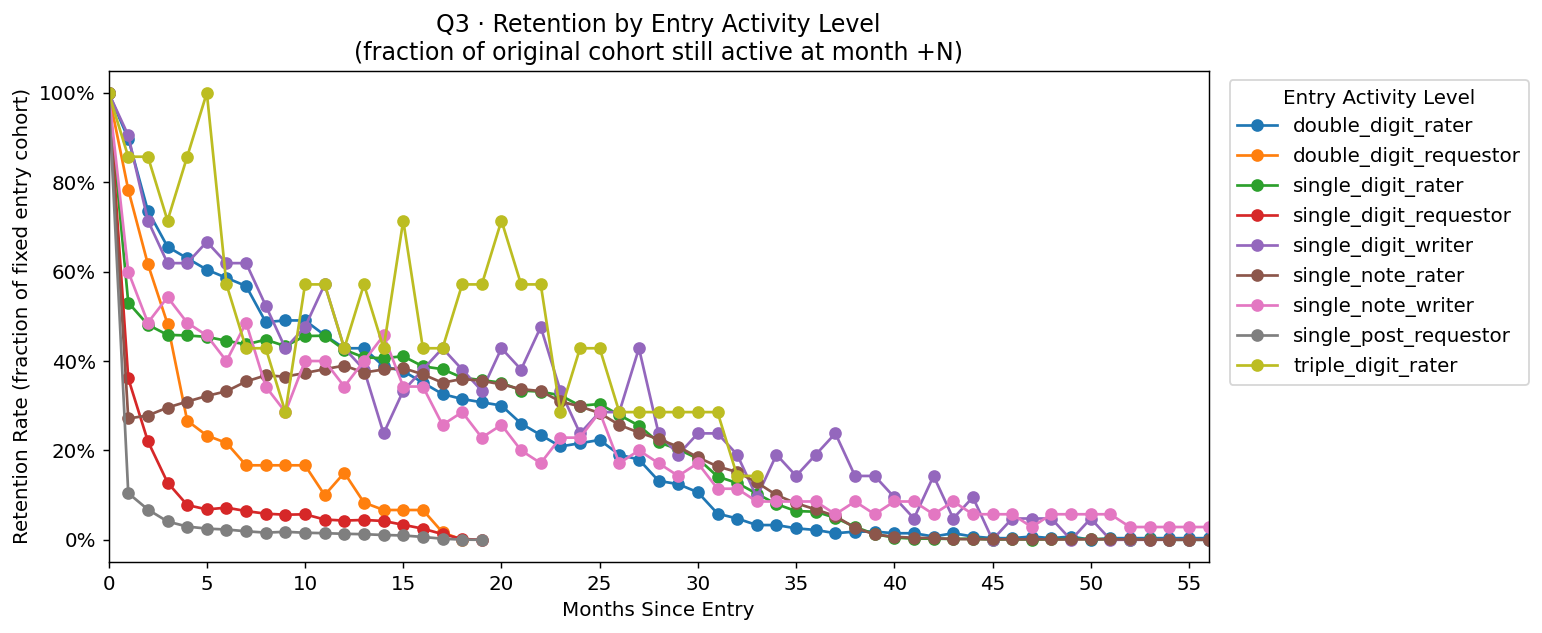

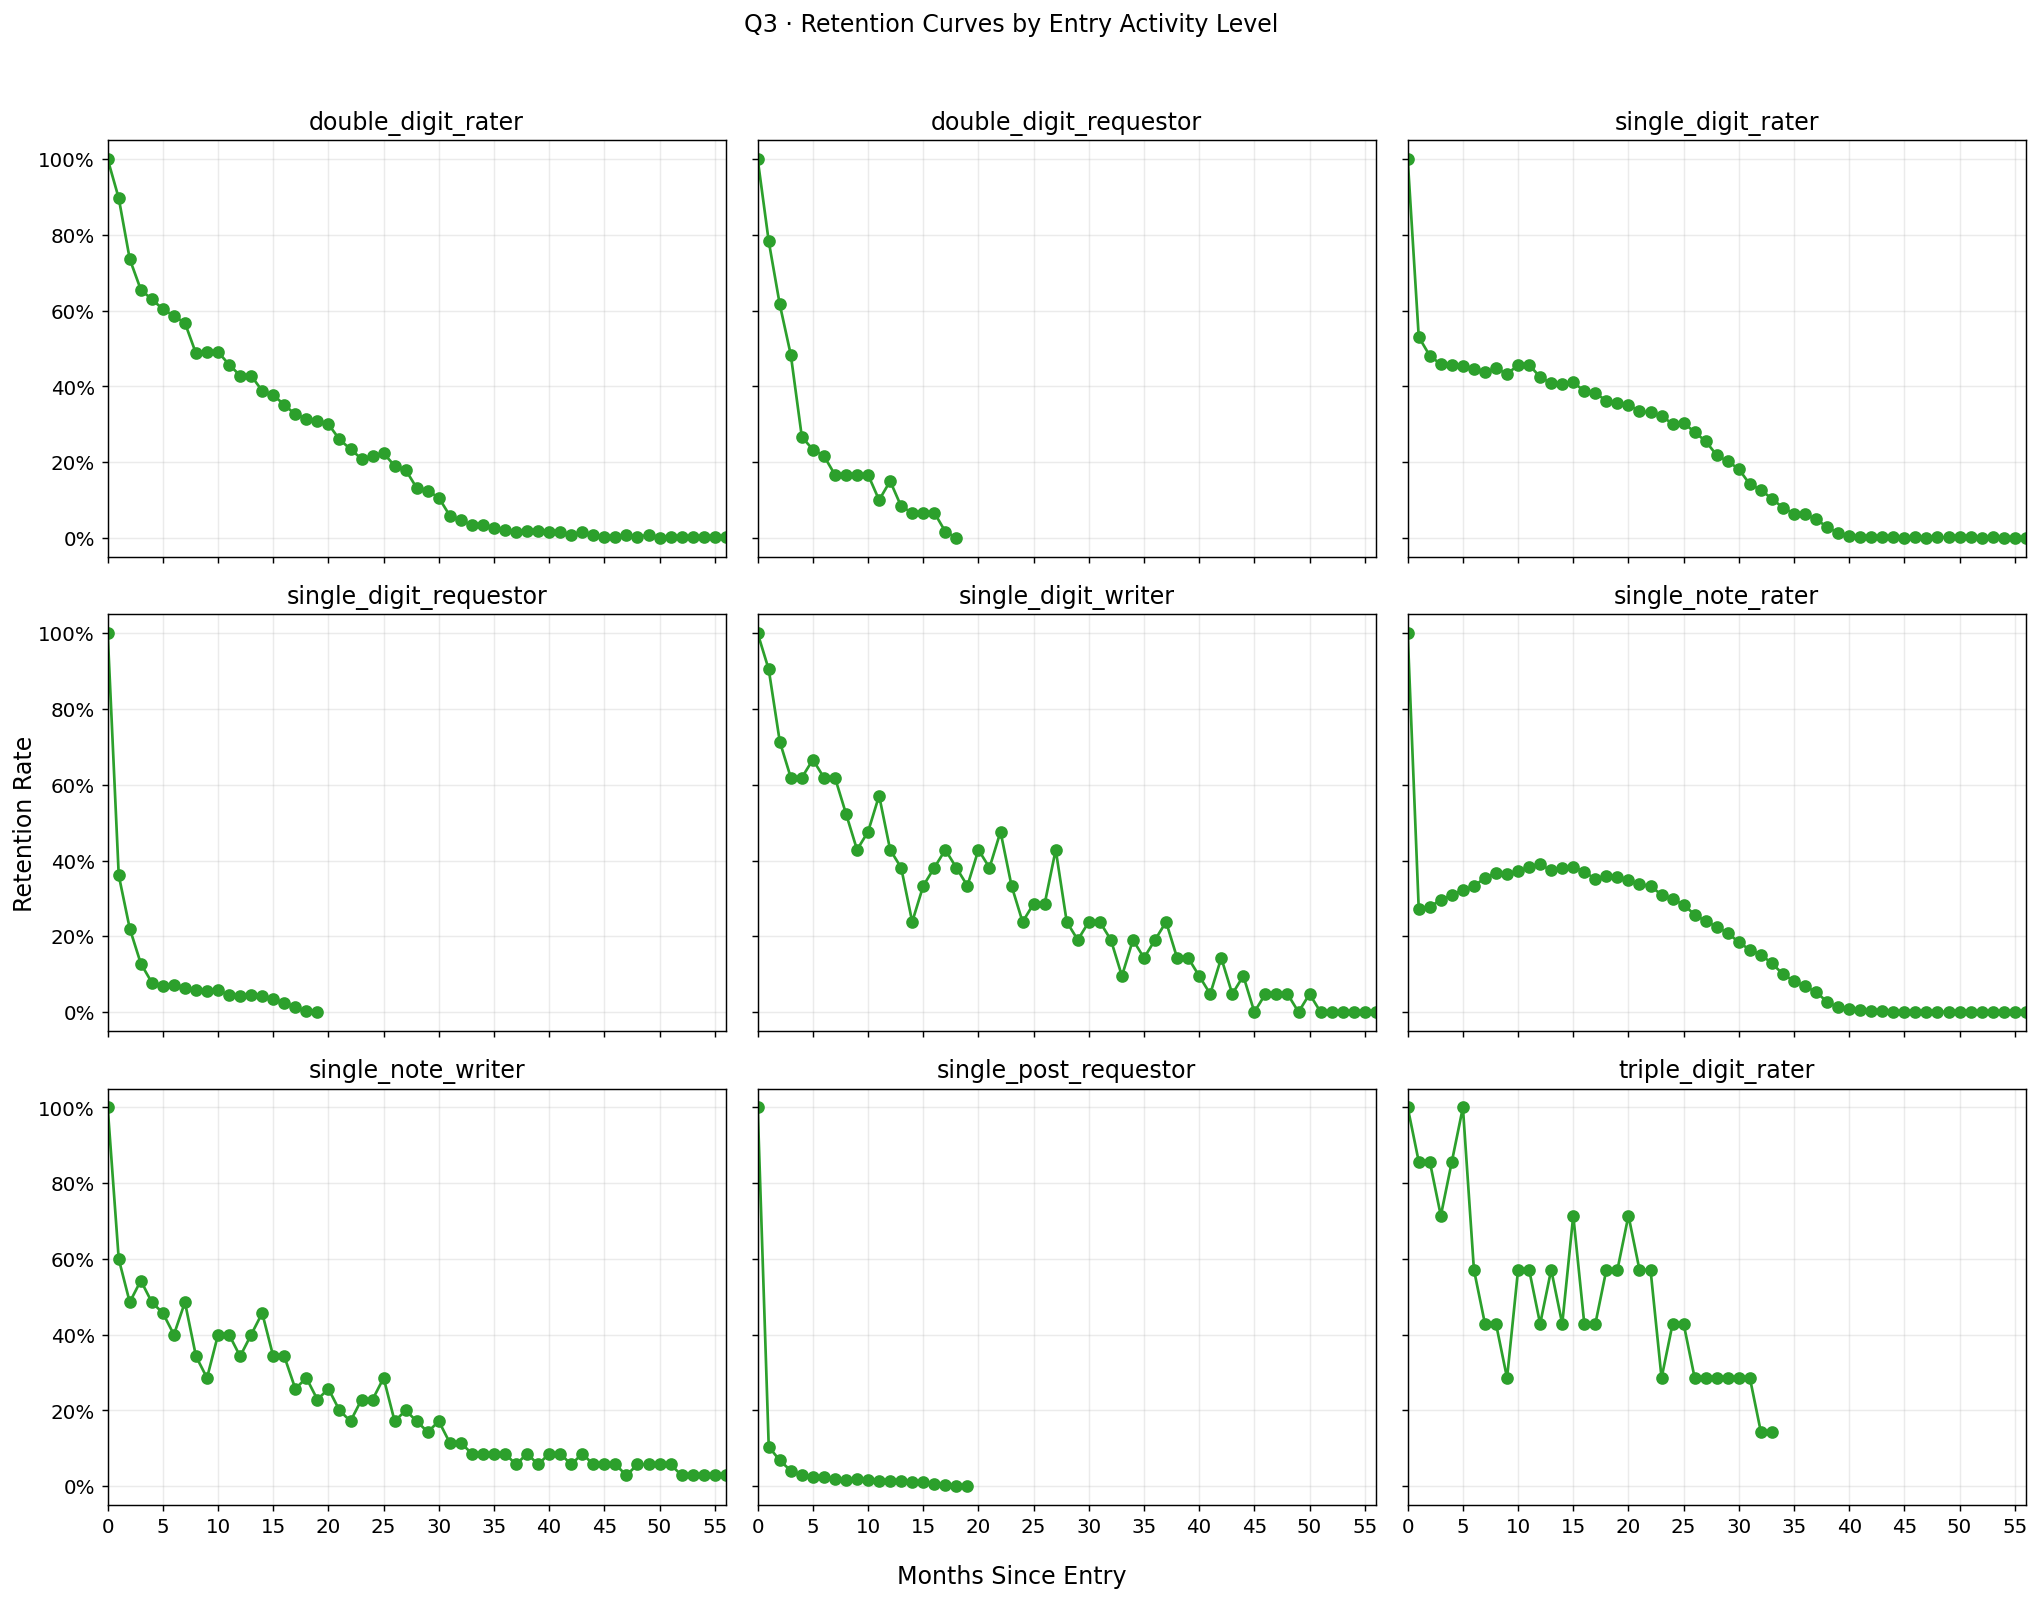

In [67]:
# Survival-style retention: for each participant, track whether they're still active at month +N
# Denominator is fixed to the full entry cohort size for each activity level

max_window = 56  # how many months out to track

# Get each participant's entry month and entry role
entrants = (
    df.filter(pl.col("activeMonth"))
    .group_by("participantId")
    .agg([
        pl.col("userMonth").min().alias("entry_month"),
        pl.col("month_role").sort_by("userMonth").first().alias("entry_role"),
    ])
)

cohort_sizes = entrants.group_by("entry_role").agg(pl.len().alias("cohort_size"))

# Join back to full df to get activeMonth at each userMonth
joined = (
    df.join(entrants, on="participantId", how="left")
    .with_columns(
        (pl.col("userMonth") - pl.col("entry_month")).alias("months_since_entry")
    )
    .filter(pl.col("months_since_entry").is_between(0, max_window))
)

# For each entry_role × months_since_entry, compute active count using a fixed cohort denominator
retention = (
    joined.group_by(["entry_role", "months_since_entry"])
    .agg(pl.col("activeMonth").sum().alias("still_active"))
    .join(cohort_sizes, on="entry_role", how="left")
    .with_columns(
        (pl.col("still_active") / pl.col("cohort_size")).alias("retention_rate")
    )
    .sort(["entry_role", "months_since_entry"])
)

roles_sorted = sorted(retention["entry_role"].unique().to_list())
tick_step = 5
tick_positions = list(range(0, max_window + 1, tick_step))

# Combined graph
fig, ax = plt.subplots(figsize=(12, 5))
for role in roles_sorted:
    subset = retention.filter(pl.col("entry_role") == role)
    ax.plot(
        subset["months_since_entry"].to_list(),
        subset["retention_rate"].to_list(),
        marker="o", label=str(role)
    )

ax.set_xlabel("Months Since Entry")
ax.set_ylabel("Retention Rate (fraction of fixed entry cohort)")
ax.set_title("Q3 · Retention by Entry Activity Level\n(fraction of original cohort still active at month +N)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(title="Entry Activity Level", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlim(0, max_window)
ax.set_xticks(tick_positions)
plt.tight_layout()
plt.show()

# Per-activity-level graphs
n_roles = len(roles_sorted)
n_cols = 3
n_rows = int(np.ceil(n_roles / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, role in enumerate(roles_sorted):
    ax = axes[i]
    subset = retention.filter(pl.col("entry_role") == role)
    ax.plot(
        subset["months_since_entry"].to_list(),
        subset["retention_rate"].to_list(),
        marker="o", color="#2ca02c"
    )
    ax.set_title(str(role))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(alpha=0.25)

for j in range(n_roles, len(axes)):
    axes[j].axis("off")

for ax in axes:
    if ax.get_visible():
        ax.set_xlim(0, max_window)
        ax.set_xticks(tick_positions)

fig.suptitle("Q3 · Retention Curves by Entry Activity Level", y=1.02)
fig.supxlabel("Months Since Entry")
fig.supylabel("Retention Rate")
plt.tight_layout()
plt.show()